# 03 — Internal Baseline Evaluation

**Phase 5 (Section 3.5.1)** of the SurfSense ML pipeline.

Compares the ML model against the rule-based scorer on the held-out test set,
using the physics-grounded synthetic label (ml/labels.py) as ground truth.

Metric groups:
- **Regression**: MAE, RMSE, R²
- **Classification**: Accuracy, macro F1 over the four rating classes
- **Ranking**: Spearman's ρ

Plus per-spot and per-season breakdowns, confusion matrices, and SHAP plots.

Run from `ml/notebooks/` or project root.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
)
import joblib
import shap

warnings.filterwarnings('ignore')
shap.initjs()

# Resolve repo root whether run from ml/notebooks/ or project root
cwd = Path().resolve()
if cwd.name == 'notebooks':
    REPO = cwd.parents[1]
elif cwd.name == 'ml':
    REPO = cwd.parent
else:
    REPO = cwd  # assume project root

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

PROCESSED = REPO / 'ml/data/processed'
MODELS    = REPO / 'ml/models'
FIGURES   = REPO / 'ml/figures'
EVAL_OUT  = REPO / 'evaluation'

FIGURES.mkdir(parents=True, exist_ok=True)
EVAL_OUT.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150  # screen; saved at 300 DPI

RATING_ORDER = ['unsafe', 'challenging', 'suitable', 'ideal']
THRESHOLDS   = {'max_wave_height': 2.5, 'max_wind_speed': 20.0}  # intermediate

print(f'REPO: {REPO}')
print(f'FIGURES: {FIGURES}')
print(f'EVAL_OUT: {EVAL_OUT}')

REPO: /Users/jwehr/Desktop/Master Thesis Project/SurfSense
FIGURES: /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures
EVAL_OUT: /Users/jwehr/Desktop/Master Thesis Project/SurfSense/evaluation


## 1. Load test set

In [2]:
test  = pd.read_parquet(PROCESSED / 'test.parquet').reset_index(drop=True)
train = pd.read_parquet(PROCESSED / 'train.parquet').reset_index(drop=True)

test['timestamp'] = pd.to_datetime(test['timestamp'])
test['month']     = test['timestamp'].dt.month
test['season']    = test['month'].map({
    12: 'DJF', 1: 'DJF', 2: 'DJF',
     3: 'MAM', 4: 'MAM', 5: 'MAM',
     6: 'JJA', 7: 'JJA', 8: 'JJA',
     9: 'SON', 10: 'SON', 11: 'SON',
})

print(f'Test rows : {len(test):,}')
print(f'Date range: {test["timestamp"].min().date()} → {test["timestamp"].max().date()}')
print('Spots     :', test['spot_id'].value_counts().to_dict())
print('Seasons   :', test['season'].value_counts().to_dict())

Test rows : 13,158
Date range: 2026-01-06 → 2026-04-25
Spots     : {'hossegor': 2632, 'pipeline': 2632, 'ericeira': 2632, 'gold_coast': 2631, 'jeffreys_bay': 2631}
Seasons   : {'MAM': 6720, 'DJF': 6438}


## 2. Synthetic labels (ground truth)

In [3]:
from ml.labels import compute_synthetic_score

y_true = test.apply(compute_synthetic_score, axis=1).values

print(f'y_true  n={len(y_true):,}  min={y_true.min():.1f}  '
      f'max={y_true.max():.1f}  mean={y_true.mean():.1f}  std={y_true.std():.1f}')

y_true  n=13,158  min=18.9  max=97.3  mean=40.1  std=15.3


## 3. ML predictions

In [4]:
from app.ml.feature_extractor import FEATURE_NAMES, ForecastPointFeatureExtractor

model   = joblib.load(MODELS / 'surf_condition_model.joblib')
imputer = joblib.load(MODELS / 'imputer.joblib')

extractor  = ForecastPointFeatureExtractor()
X_test     = extractor.transform_batch(test, skill_level='intermediate')
X_test_imp = imputer.transform(X_test)
y_ml       = np.clip(model.predict(X_test_imp), 0, 100)

print(f'y_ml  min={y_ml.min():.1f}  max={y_ml.max():.1f}  mean={y_ml.mean():.1f}')
print(f'Features: {len(FEATURE_NAMES)}')

y_ml  min=14.5  max=95.9  mean=40.0
Features: 26


## 4. Rule-based predictions

In [5]:
from app.planning.scoring import rule_based_score, derive_rating

def _is_offshore(wind_deg: float, swell_deg: float) -> bool:
    diff = (wind_deg - (swell_deg + 180.0)) % 360.0
    return diff < 90.0 or diff > 270.0

def row_rule_score(row) -> float:
    return rule_based_score(
        wave_avg    = float(row.get('wave_height_m', 0) or 0),
        wind_speed  = float(row.get('wind_speed_kph', 0) or 0),
        swell_period= float(row.get('swell_period_s', 0) or 0),
        is_offshore = _is_offshore(
            float(row.get('wind_direction_deg', 270) or 270),
            float(row.get('swell_direction_deg', 270) or 270),
        ),
        thresholds  = THRESHOLDS,
    )

y_rule = test.apply(row_rule_score, axis=1).values

print(f'y_rule  min={y_rule.min():.1f}  max={y_rule.max():.1f}  mean={y_rule.mean():.1f}')

y_rule  min=0.0  max=80.0  mean=48.6


## 5. Derive ratings

In [6]:
def _row_derive_rating(score: float, row) -> str:
    return derive_rating(
        score     = score,
        wave_avg  = float(row.get('wave_height_m', 0) or 0),
        wind_speed= float(row.get('wind_speed_kph', 0) or 0),
        thresholds= THRESHOLDS,
    )

r_true = [_row_derive_rating(s, row) for s, (_, row) in zip(y_true, test.iterrows())]
r_ml   = [_row_derive_rating(s, row) for s, (_, row) in zip(y_ml,   test.iterrows())]
r_rule = [_row_derive_rating(s, row) for s, (_, row) in zip(y_rule, test.iterrows())]

import collections
print('Ground truth ratings:', dict(collections.Counter(r_true)))
print('ML ratings          :', dict(collections.Counter(r_ml)))
print('Rule ratings        :', dict(collections.Counter(r_rule)))

Ground truth ratings: {'suitable': 3090, 'challenging': 8376, 'unsafe': 1415, 'ideal': 277}
ML ratings          : {'suitable': 2730, 'challenging': 8749, 'unsafe': 1415, 'ideal': 264}
Rule ratings        : {'suitable': 6022, 'challenging': 4924, 'unsafe': 1415, 'ideal': 797}


## 6. Overall metrics

In [7]:
def regression_metrics(y_pred, y_t):
    return {
        'MAE' : round(mean_absolute_error(y_t, y_pred), 4),
        'RMSE': round(float(np.sqrt(mean_squared_error(y_t, y_pred))), 4),
        'R2'  : round(r2_score(y_t, y_pred), 4),
    }

def classification_metrics(r_pred, r_t):
    return {
        'Accuracy': round(accuracy_score(r_t, r_pred), 4),
        'F1_macro': round(f1_score(r_t, r_pred, average='macro',
                                   labels=RATING_ORDER, zero_division=0), 4),
    }

def ranking_metric(y_pred, y_t):
    rho, pval = stats.spearmanr(y_t, y_pred)
    return {'Spearman_rho': round(float(rho), 4), 'p_value': round(float(pval), 6)}

metrics_ml   = {**regression_metrics(y_ml, y_true),
                **classification_metrics(r_ml, r_true),
                **ranking_metric(y_ml, y_true)}
metrics_rule = {**regression_metrics(y_rule, y_true),
                **classification_metrics(r_rule, r_true),
                **ranking_metric(y_rule, y_true)}

summary = pd.DataFrame({'ML': metrics_ml, 'Rule-based': metrics_rule}).T
print(summary.to_string())

                MAE     RMSE      R2  Accuracy  F1_macro  Spearman_rho  p_value
ML           2.0599   3.5901  0.9449    0.9397    0.9234        0.9502      0.0
Rule-based  12.7215  15.1606  0.0170    0.6415    0.6629        0.6657      0.0


## 7. Per-spot breakdown

In [8]:
def per_slice_metrics(df, y_pred, y_t, r_pred, r_t, slice_col):
    rows = []
    idx  = df.index.tolist()
    for val in sorted(df[slice_col].unique()):
        mask = (df[slice_col] == val).values
        yp = y_pred[mask]
        yt = y_t[mask]
        rp = [r for r, m in zip(r_pred, mask) if m]
        rt = [r for r, m in zip(r_t,    mask) if m]
        rows.append({
            slice_col: val, 'n': mask.sum(),
            'R2'        : round(r2_score(yt, yp), 3),
            'MAE'       : round(mean_absolute_error(yt, yp), 3),
            'RMSE'      : round(float(np.sqrt(mean_squared_error(yt, yp))), 3),
            'Accuracy'  : round(accuracy_score(rt, rp), 3),
            'F1_macro'  : round(f1_score(rt, rp, average='macro',
                                         labels=RATING_ORDER, zero_division=0), 3),
            'Spearman'  : round(float(stats.spearmanr(yt, yp)[0]), 3),
        })
    return pd.DataFrame(rows)

spot_ml   = per_slice_metrics(test, y_ml,   y_true, r_ml,   r_true, 'spot_id')
spot_rule = per_slice_metrics(test, y_rule, y_true, r_rule, r_true, 'spot_id')

print('ML per spot:')
print(spot_ml.to_string(index=False))
print('\nRule-based per spot:')
print(spot_rule.to_string(index=False))

ML per spot:
     spot_id    n    R2   MAE  RMSE  Accuracy  F1_macro  Spearman
    ericeira 2632 0.983 1.182 2.036     0.963     0.921     0.990
  gold_coast 2631 0.837 2.282 3.624     0.952     0.669     0.843
    hossegor 2632 0.991 1.013 1.550     0.963     0.954     0.996
jeffreys_bay 2631 0.704 2.652 4.514     0.964     0.676     0.775
    pipeline 2632 0.825 3.170 4.939     0.857     0.902     0.886

Rule-based per spot:
     spot_id    n     R2    MAE   RMSE  Accuracy  F1_macro  Spearman
    ericeira 2632 -0.342 15.230 18.239     0.576     0.539     0.388
  gold_coast 2631 -1.201 11.797 13.319     0.773     0.560     0.760
    hossegor 2632 -0.039 13.457 16.395     0.586     0.629     0.628
jeffreys_bay 2631 -1.564 11.667 13.289     0.716     0.522     0.595
    pipeline 2632 -0.392 11.456 13.919     0.556     0.631     0.513


## 8. Per-season breakdown

In [9]:
season_ml   = per_slice_metrics(test, y_ml,   y_true, r_ml,   r_true, 'season')
season_rule = per_slice_metrics(test, y_rule, y_true, r_rule, r_true, 'season')

print('ML per season:')
print(season_ml.to_string(index=False))
print('\nRule-based per season:')
print(season_rule.to_string(index=False))

ML per season:
season    n    R2   MAE  RMSE  Accuracy  F1_macro  Spearman
   DJF 6438 0.967 1.793 2.968     0.956     0.935     0.970
   MAM 6720 0.916 2.316 4.099     0.924     0.914     0.922

Rule-based per season:
season    n     R2    MAE   RMSE  Accuracy  F1_macro  Spearman
   DJF 6438  0.038 13.012 15.976     0.691     0.650     0.629
   MAM 6720 -0.024 12.443 14.336     0.594     0.679     0.701


## 9. Write `evaluation/baseline_vs_ml.csv`

In [10]:
records = []

# Overall
for metric, val in metrics_ml.items():
    records.append({'metric': metric, 'system': 'ml',   'split_slice': 'overall', 'score': val})
for metric, val in metrics_rule.items():
    records.append({'metric': metric, 'system': 'rule', 'split_slice': 'overall', 'score': val})

# Per-spot ML
for _, row in spot_ml.iterrows():
    for m in ['R2','MAE','RMSE','Accuracy','F1_macro','Spearman']:
        records.append({'metric': m, 'system': 'ml',   'split_slice': f'spot_{row["spot_id"]}', 'score': row[m]})
for _, row in spot_rule.iterrows():
    for m in ['R2','MAE','RMSE','Accuracy','F1_macro','Spearman']:
        records.append({'metric': m, 'system': 'rule', 'split_slice': f'spot_{row["spot_id"]}', 'score': row[m]})

# Per-season ML
for _, row in season_ml.iterrows():
    for m in ['R2','MAE','RMSE','Accuracy','F1_macro','Spearman']:
        records.append({'metric': m, 'system': 'ml',   'split_slice': f'season_{row["season"]}', 'score': row[m]})
for _, row in season_rule.iterrows():
    for m in ['R2','MAE','RMSE','Accuracy','F1_macro','Spearman']:
        records.append({'metric': m, 'system': 'rule', 'split_slice': f'season_{row["season"]}', 'score': row[m]})

csv_path = EVAL_OUT / 'baseline_vs_ml.csv'
pd.DataFrame(records).to_csv(csv_path, index=False)
print(f'Written {len(records)} rows to {csv_path}')

Written 98 rows to /Users/jwehr/Desktop/Master Thesis Project/SurfSense/evaluation/baseline_vs_ml.csv


## 10. Score distribution

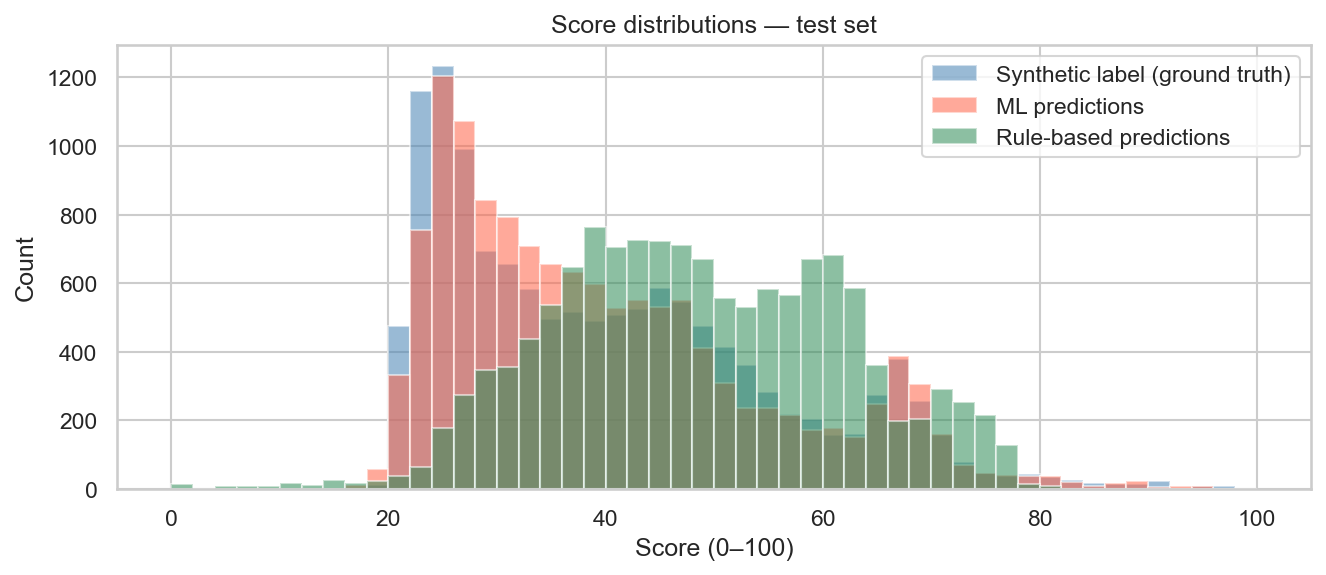

Saved /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/score_distribution.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 100, 51)
ax.hist(y_true, bins=bins, alpha=0.55, label='Synthetic label (ground truth)', color='steelblue')
ax.hist(y_ml,   bins=bins, alpha=0.55, label='ML predictions',                  color='tomato')
ax.hist(y_rule, bins=bins, alpha=0.55, label='Rule-based predictions',           color='seagreen')
ax.set_xlabel('Score (0–100)')
ax.set_ylabel('Count')
ax.set_title('Score distributions — test set')
ax.legend()
plt.tight_layout()
p = FIGURES / 'score_distribution.png'
fig.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {p}')

## 11. Scatter: predicted vs actual

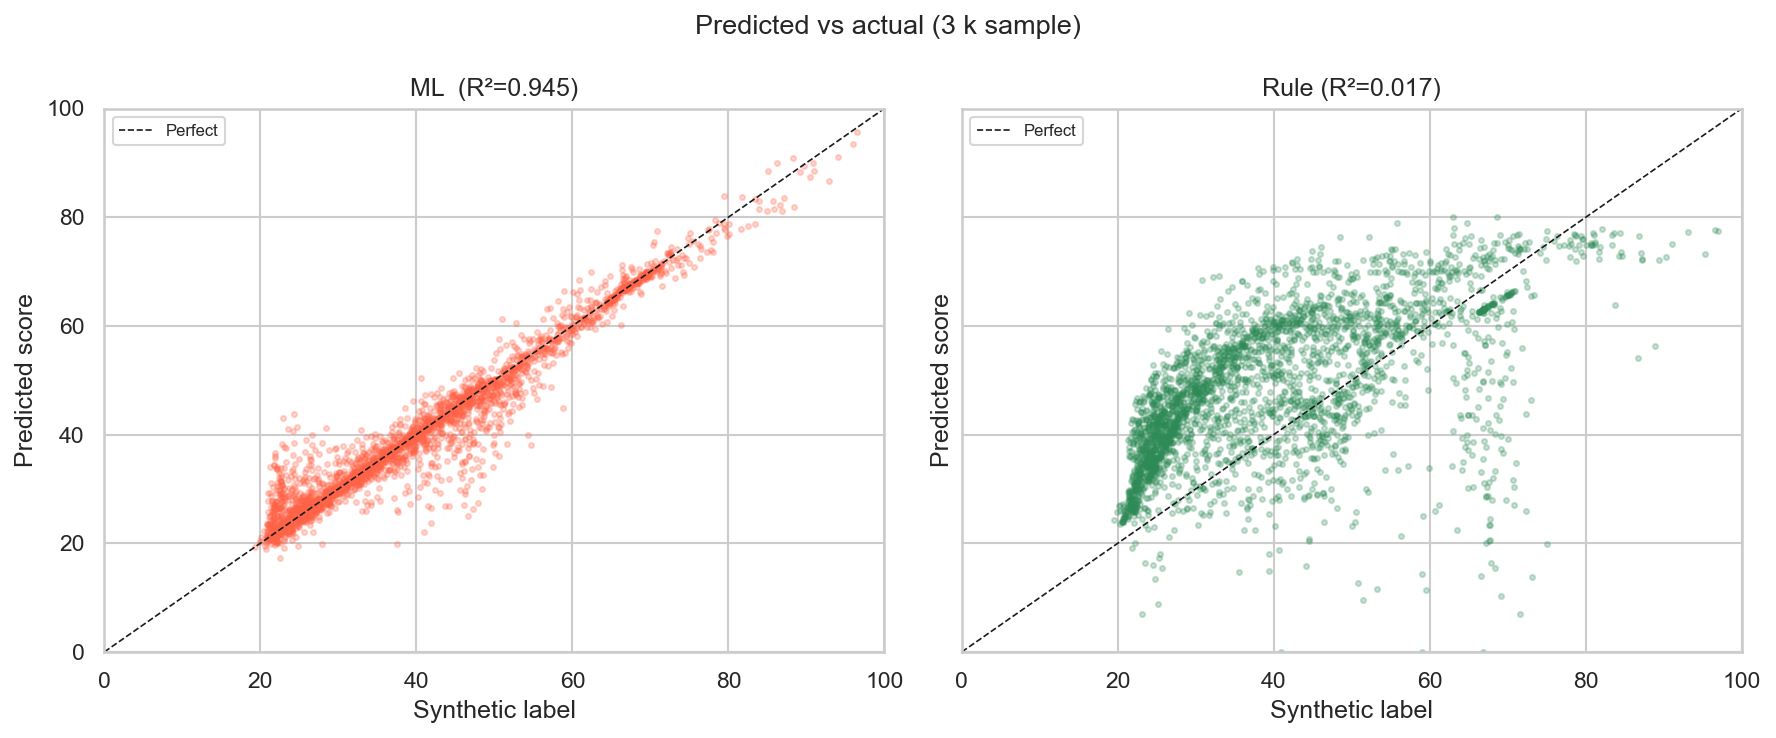

Saved /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/scatter_pred_actual.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, y_pred, label, color in [
    (axes[0], y_ml,   f'ML  (R²={metrics_ml["R2"]:.3f})',   'tomato'),
    (axes[1], y_rule, f'Rule (R²={metrics_rule["R2"]:.3f})', 'seagreen'),
]:
    idx = np.random.choice(len(y_true), size=min(3000, len(y_true)), replace=False)
    ax.scatter(y_true[idx], y_pred[idx], alpha=0.25, s=6, color=color)
    lims = [0, 100]
    ax.plot(lims, lims, 'k--', lw=0.8, label='Perfect')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Synthetic label')
    ax.set_ylabel('Predicted score')
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.suptitle('Predicted vs actual (3 k sample)', fontsize=13)
plt.tight_layout()
p = FIGURES / 'scatter_pred_actual.png'
fig.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {p}')

## 12. Confusion matrices

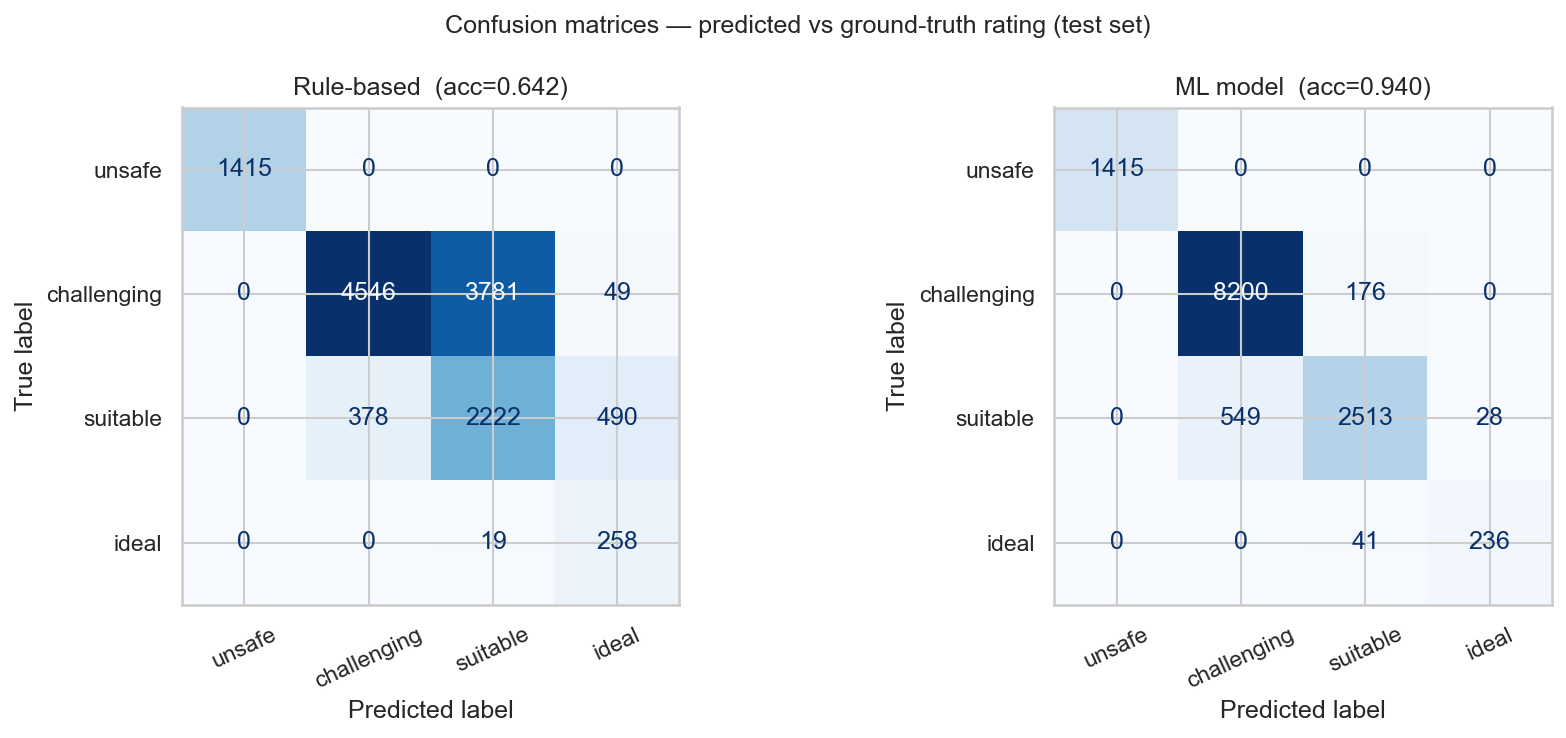

Saved /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/confusion_rule.png
Saved /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/confusion_ml.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, r_pred, title, fname in [
    (axes[0], r_rule, 'Rule-based', 'confusion_rule.png'),
    (axes[1], r_ml,   'ML model',   'confusion_ml.png'),
]:
    cm = confusion_matrix(r_true, r_pred, labels=RATING_ORDER)
    disp = ConfusionMatrixDisplay(cm, display_labels=RATING_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(r_true, r_pred)
    ax.set_title(f'{title}  (acc={acc:.3f})')
    ax.tick_params(axis='x', rotation=25)

fig.suptitle('Confusion matrices — predicted vs ground-truth rating (test set)', fontsize=12)
plt.tight_layout()
p = FIGURES / 'confusion_matrices.png'
fig.savefig(p, dpi=300, bbox_inches='tight')
plt.show()

# Also save individually
for r_pred, fname in [(r_rule, 'confusion_rule.png'), (r_ml, 'confusion_ml.png')]:
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(r_true, r_pred, labels=RATING_ORDER)
    ConfusionMatrixDisplay(cm, display_labels=RATING_ORDER).plot(ax=ax2, colorbar=False, cmap='Blues')
    ax2.tick_params(axis='x', rotation=25)
    fig2.tight_layout()
    fig2.savefig(FIGURES / fname, dpi=300, bbox_inches='tight')
    plt.close(fig2)
    print(f'Saved {FIGURES / fname}')

## 13. Per-spot accuracy

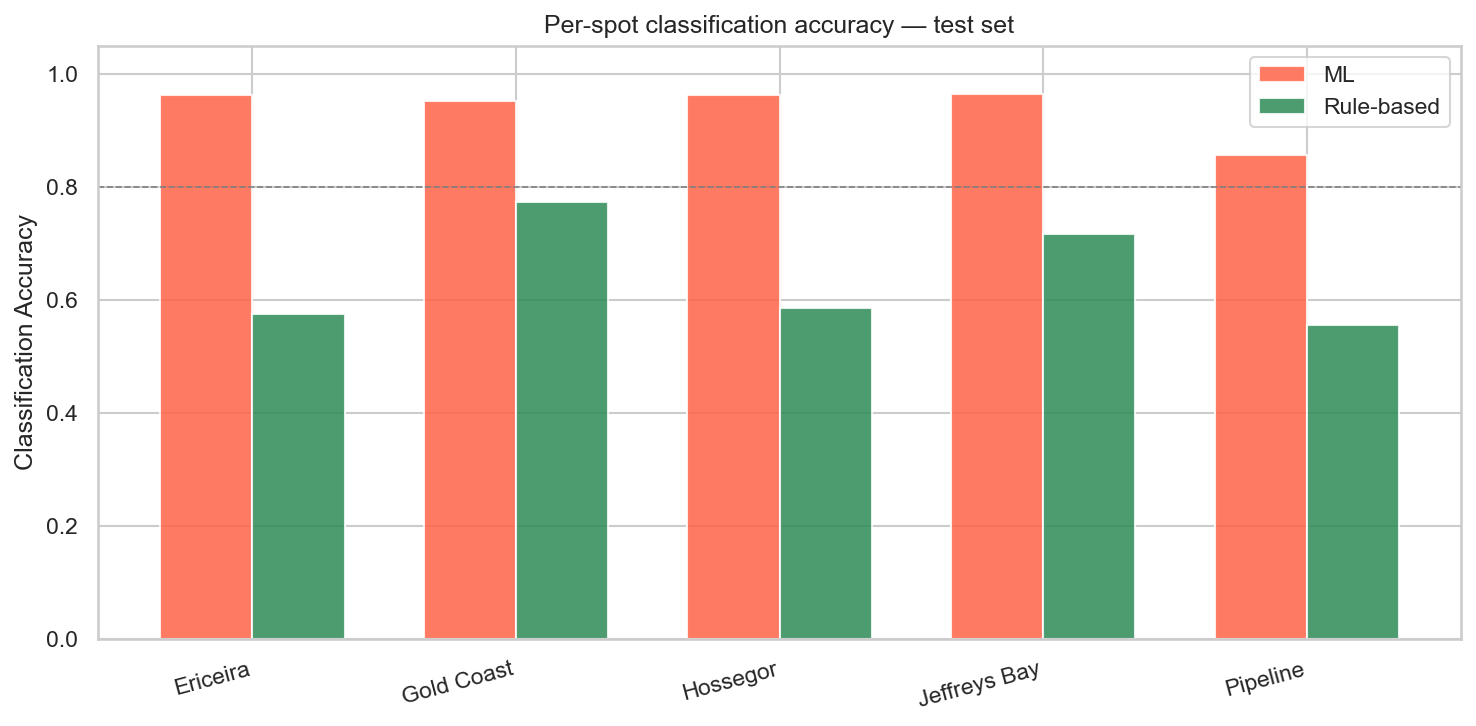

Saved /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/per_spot_accuracy.png


In [14]:
spots = spot_ml['spot_id'].tolist()
x = np.arange(len(spots))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, spot_ml['Accuracy'],   w, label='ML',         color='tomato',   alpha=0.85)
ax.bar(x + w/2, spot_rule['Accuracy'], w, label='Rule-based', color='seagreen', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([s.replace('_', ' ').title() for s in spots], rotation=15, ha='right')
ax.set_ylabel('Classification Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Per-spot classification accuracy — test set')
ax.legend()
ax.axhline(0.8, color='gray', linestyle='--', lw=0.8, label='80 % threshold')
plt.tight_layout()
p = FIGURES / 'per_spot_accuracy.png'
fig.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {p}')

## 14. Per-season accuracy

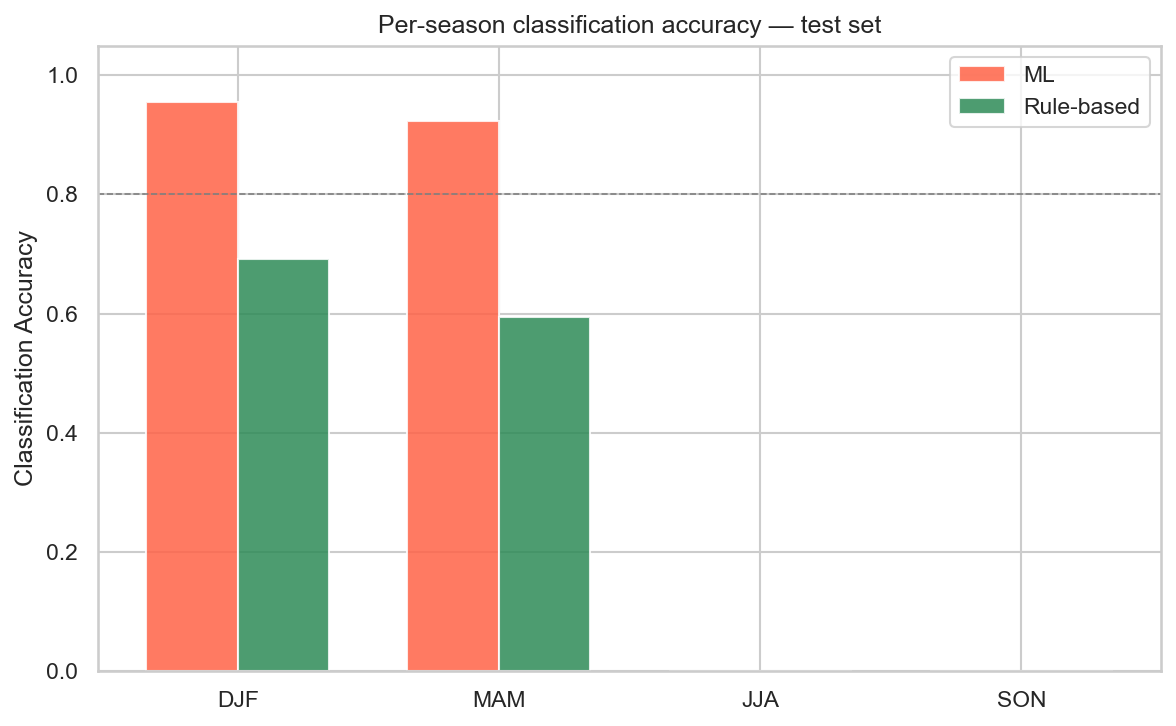

Saved /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/per_season_accuracy.png


In [15]:
seasons = ['DJF', 'MAM', 'JJA', 'SON']
sm_acc  = season_ml.set_index('season')['Accuracy'].reindex(seasons, fill_value=0)
sr_acc  = season_rule.set_index('season')['Accuracy'].reindex(seasons, fill_value=0)

x = np.arange(len(seasons))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, sm_acc.values, w, label='ML',         color='tomato',   alpha=0.85)
ax.bar(x + w/2, sr_acc.values, w, label='Rule-based', color='seagreen', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Classification Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Per-season classification accuracy — test set')
ax.legend()
ax.axhline(0.8, color='gray', linestyle='--', lw=0.8)
plt.tight_layout()
p = FIGURES / 'per_season_accuracy.png'
fig.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {p}')

## 15. SHAP — beeswarm and feature importance

In [16]:
# Use a 2000-row sample for SHAP to keep runtime < 1 min
idx_shap = np.random.choice(len(X_test_imp), size=min(2000, len(X_test_imp)), replace=False)
X_shap   = X_test_imp[idx_shap]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print('SHAP values shape:', shap_values.shape)

SHAP values shape: (2000, 26)


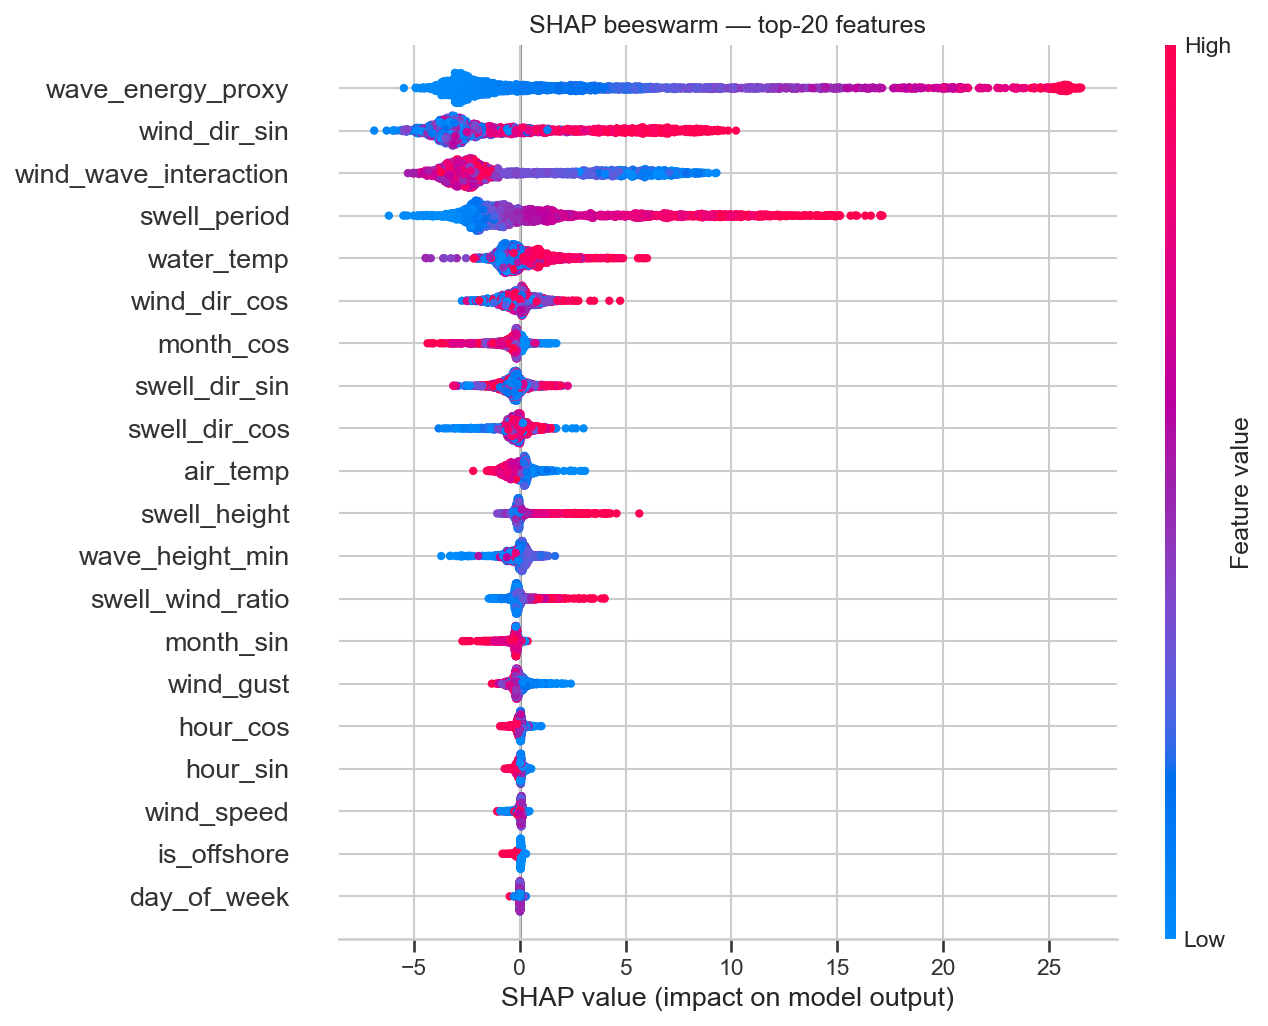

Saved /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/shap_beeswarm.png


In [17]:
# Beeswarm
fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURE_NAMES,
    plot_type='dot',
    show=False,
    max_display=20,
    plot_size=None,
)
plt.title('SHAP beeswarm — top-20 features', fontsize=12)
plt.tight_layout()
p = FIGURES / 'shap_beeswarm.png'
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {p}')

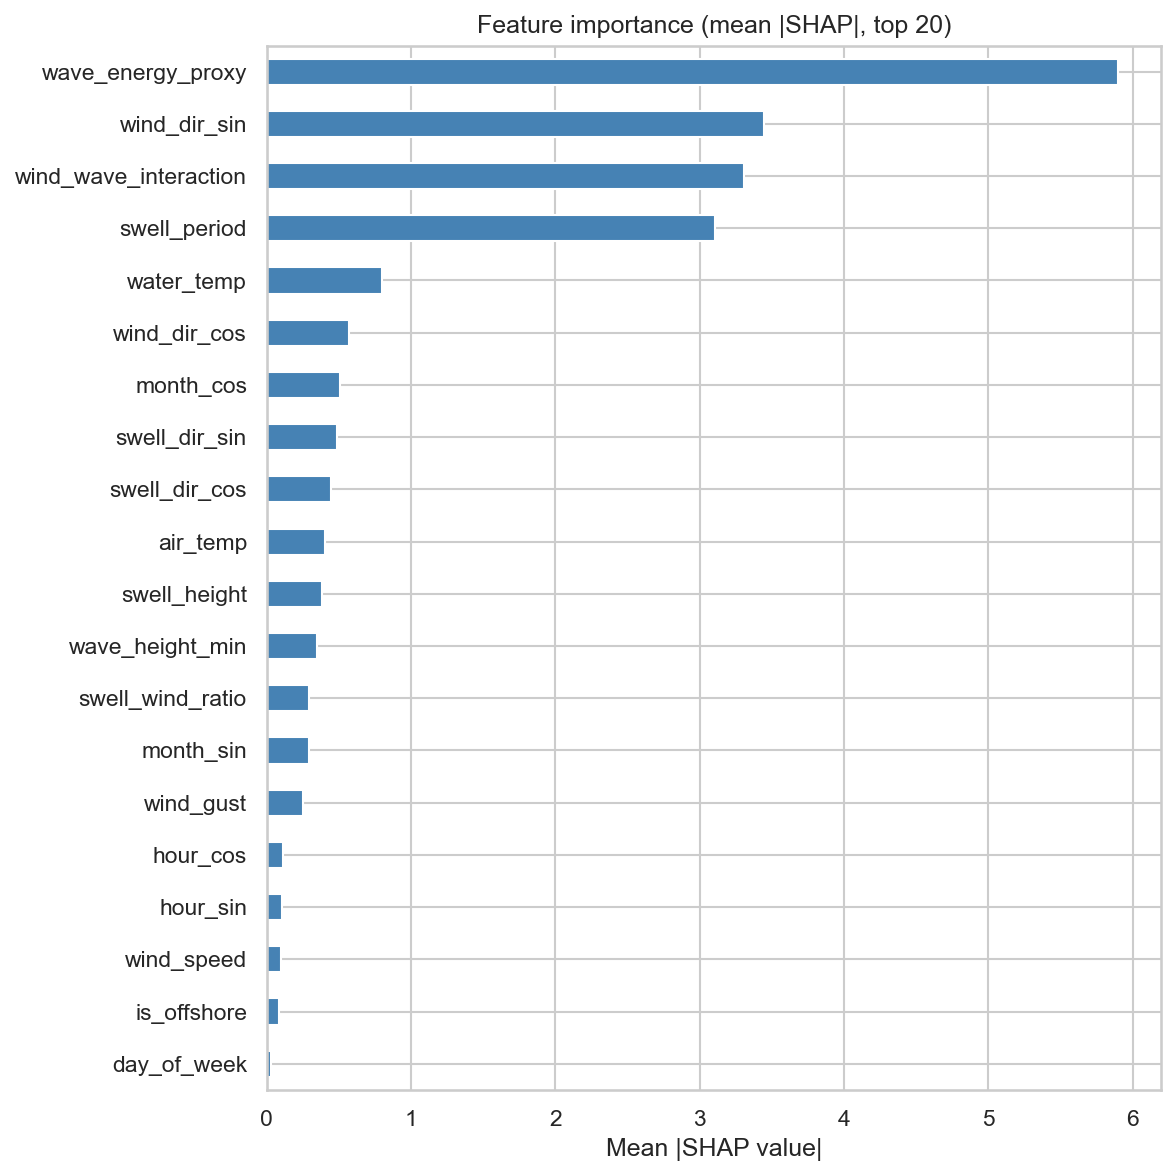

Saved /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/feature_importance.png


In [18]:
# Feature importance bar (mean |SHAP|)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=FEATURE_NAMES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
feat_imp.tail(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature importance (mean |SHAP|, top 20)')
plt.tight_layout()
p = FIGURES / 'feature_importance.png'
fig.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {p}')

Top-3 features: ['wave_energy_proxy', 'wind_dir_sin', 'wind_wave_interaction']


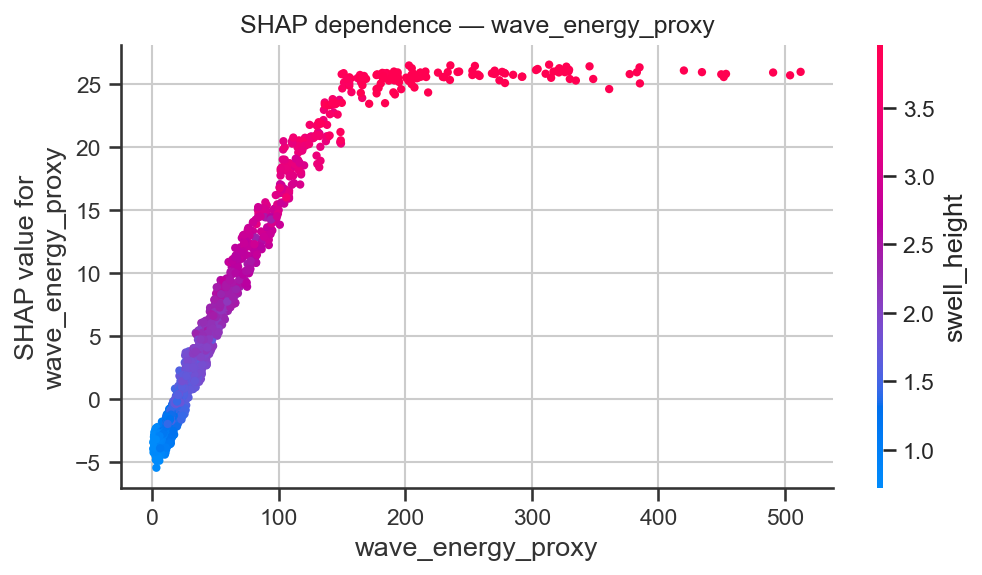

Saved /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/shap_dep_1.png


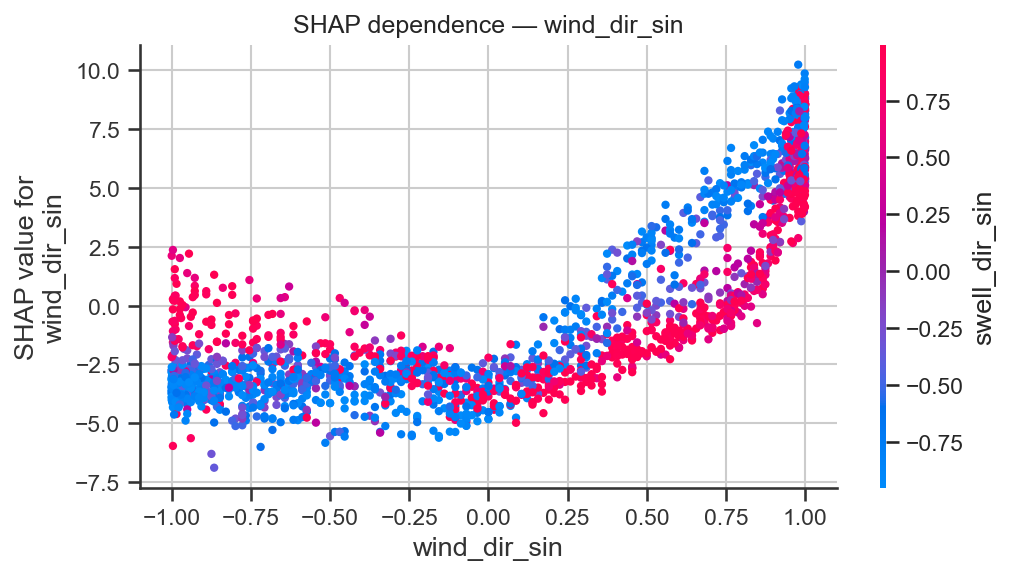

Saved /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/shap_dep_2.png


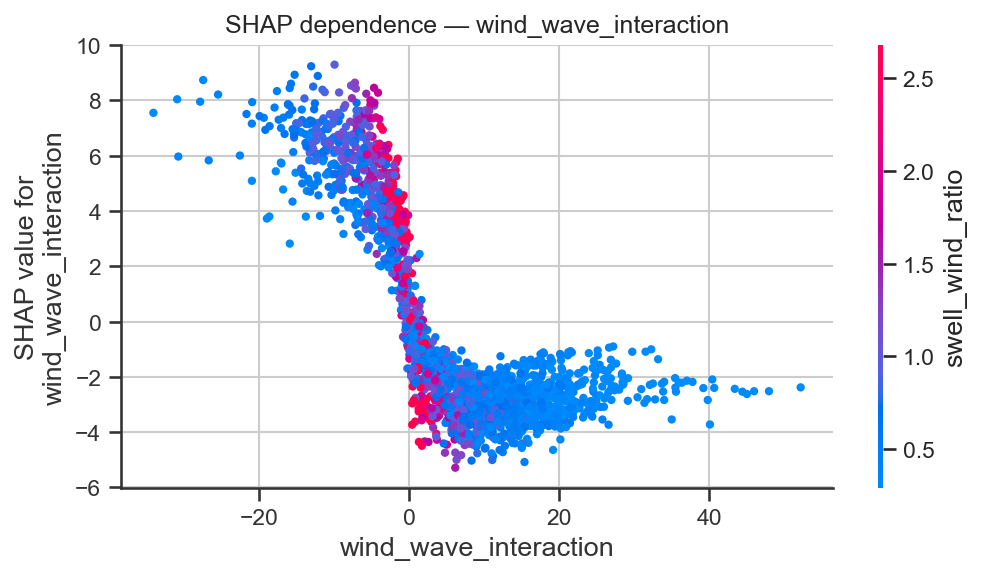

Saved /Users/jwehr/Desktop/Master Thesis Project/SurfSense/ml/figures/shap_dep_3.png


In [19]:
# Top-3 SHAP dependence plots
top3 = pd.Series(mean_abs_shap, index=FEATURE_NAMES).sort_values(ascending=False).head(3).index.tolist()
print('Top-3 features:', top3)

for i, feat in enumerate(top3, start=1):
    feat_idx = FEATURE_NAMES.index(feat)
    fig, ax = plt.subplots(figsize=(7, 4))
    shap.dependence_plot(
        feat_idx, shap_values, X_shap,
        feature_names=FEATURE_NAMES,
        ax=ax, show=False,
    )
    ax.set_title(f'SHAP dependence — {feat}')
    plt.tight_layout()
    p = FIGURES / f'shap_dep_{i}.png'
    fig.savefig(p, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved {p}')

## 16. Final summary

In [20]:
print('=' * 60)
print('EVALUATION SUMMARY — test set')
print('=' * 60)
print(summary.to_string())
print()
print('Acceptance thresholds (Section 3.5.3):')
ml_r2  = metrics_ml['R2']
ml_acc = metrics_ml['Accuracy']
print(f'  ML R² ≥ 0.75    : {ml_r2:.4f}  {"✓" if ml_r2 >= 0.75 else "✗"}')
print(f'  ML Acc ≥ 80 %   : {ml_acc:.4f}  {"✓" if ml_acc >= 0.80 else "✗"}')

groups = {
    'Regression (R²)'     : metrics_ml['R2']           > metrics_rule['R2'],
    'Classification (Acc)': metrics_ml['Accuracy']      > metrics_rule['Accuracy'],
    'Ranking (Spearman)'  : metrics_ml['Spearman_rho']  > metrics_rule['Spearman_rho'],
}
wins = sum(groups.values())
print(f'  ML beats rule on ≥ 2 groups : {wins}/3  {"✓" if wins >= 2 else "✗"}')
for g, w in groups.items():
    print(f'    {g}: {"ML wins" if w else "Rule wins"}')

print()
saved_figs = sorted(FIGURES.glob('*.png'))
print(f'Figures saved ({len(saved_figs)}):')
for f in saved_figs:
    print(f'  {f.name}')
print(f'\nCSV: {EVAL_OUT / "baseline_vs_ml.csv"}')

EVALUATION SUMMARY — test set
                MAE     RMSE      R2  Accuracy  F1_macro  Spearman_rho  p_value
ML           2.0599   3.5901  0.9449    0.9397    0.9234        0.9502      0.0
Rule-based  12.7215  15.1606  0.0170    0.6415    0.6629        0.6657      0.0

Acceptance thresholds (Section 3.5.3):
  ML R² ≥ 0.75    : 0.9449  ✓
  ML Acc ≥ 80 %   : 0.9397  ✓
  ML beats rule on ≥ 2 groups : 3/3  ✓
    Regression (R²): ML wins
    Classification (Acc): ML wins
    Ranking (Spearman): ML wins

Figures saved (12):
  confusion_matrices.png
  confusion_ml.png
  confusion_rule.png
  feature_importance.png
  per_season_accuracy.png
  per_spot_accuracy.png
  scatter_pred_actual.png
  score_distribution.png
  shap_beeswarm.png
  shap_dep_1.png
  shap_dep_2.png
  shap_dep_3.png

CSV: /Users/jwehr/Desktop/Master Thesis Project/SurfSense/evaluation/baseline_vs_ml.csv
